<a href="https://colab.research.google.com/github/masolopa/MINERIADEDATOS/blob/main/EV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
#Seleccionar uno de los modelos vistos y
#https://www.kaggle.com/datasets/catherinerasgaitis/mxmh-survey-results
#https://www.kaggle.com/code/totoro29/music-and-mental-condition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

#El contexto del data set es sobre las estimaciones de taza de pobreza multidimensional por comuna en Chile del año 2015
#Integrantes: Alejandra Guzman - Macarena Lobos Sección 002D
#https://github.com/masolopa/MINERIADEDATOS

In [2]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

In [21]:
df = pd.read_csv("/content/musica_y_salud_mental.csv")

In [26]:
#Se observa el data frame 1 en bruto
df

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.00,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.50,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.00,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.50,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.00,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.00,Yes,Yes,Yes,Jazz,Yes,Yes,86.0,Rarely,Sometimes,Never,Never,Never,Sometimes,Very frequently,Very frequently,Rarely,Very frequently,Rarely,Very frequently,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,8/27/2022 22:00:29,18.0,YouTube Music,3.00,Yes,Yes,No,Video game music,Yes,Yes,66.0,Sometimes,Never,Rarely,Sometimes,Rarely,Rarely,Sometimes,Never,Rarely,Rarely,Rarely,Rarely,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,8/27/2022 22:18:59,21.0,Spotify,1.00,Yes,No,No,K pop,Yes,Yes,95.0,Never,Never,Rarely,Never,Never,Very frequently,Rarely,Very frequently,Never,Sometimes,Never,Sometimes,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,8/27/2022 22:33:05,19.0,Spotify,6.00,Yes,No,No,Rock,No,No,94.0,Never,Very frequently,Never,Sometimes,Never,Never,Never,Never,Never,Never,Very frequently,Never,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,8/27/2022 22:44:03,18.0,I do not use a streaming service.,1.00,Yes,No,No,R&B,Yes,Yes,155.0,Rarely,Rarely,Rarely,Rarely,Sometimes,Rarely,Rarely,Never,Rarely,Rarely,Never,Sometimes,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.


In [23]:
#Se consultan los nombres de las columnas del data frame 1
print("Nombres de columnas actuales:")
print(df1.columns.tolist())

Nombres de columnas actuales:
['Timestamp', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects', 'Permissions']


In [27]:
#Se renombran las columnas del df
df.columns = ['Fecha y hora', 'Edad','App utilizada', 'Horas de escucha por día','¿Escucha música mientras trabaja?', '¿Toca algún instrumento?','¿Compone música?', '¿Cuál es su género favorito de música?', '¿Le gusta explorar nuevos artistas/géneros?', '¿Escucha música en lenguajes que usted no habla?', 'Beats por minuto de su género musical favorito', '¿Qué tan seguido escucha música clasica?', '¿Qué tan seguido escucha country?', '¿Qué tan seguido escucha electrónica?', '¿Qué tan seguido escucha folk?', '¿Qué tan seguido escucha gospel?', '¿Qué tan seguido escucha hip-hop?', '¿Qué tan seguido escucha jazz?', '¿Qué tan seguido escucha k-pop?', '¿Qué tan seguido escucha múica latina?', '¿Qué tan seguido escucha lo-fi?', '¿Qué tan seguido escucha metal?', '¿Qué tan seguido escucha pop?', '¿Qué tan seguido escucha r&b?', '¿Qué tan seguido escucha rap?', '¿Qué tan seguido escucha rock?', '¿Qué tan seguido escucha música de videojuegos?','¿Cuál es su reporte de ansiedad en escala de 1 a 10?', '¿Cuál es su reporte de depresión en escala de 1 a 10?', '¿Cuál es su reporte de insomnio en escala de 1 a 10?', '¿Cuál es su reporte de TOC en escala de 1 a 10?', '¿Cuál es el efecto que produce la música en sus condiciones de salud mental?', 'Permiso para publicar la data' ]
display(df.head())

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [30]:
#Se muestran las primeras 5 filas
df.head()

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [29]:
#Se muestran las últimas 5 filas del data frame
df.tail()

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
731,10/30/2022 14:37:28,17.0,Spotify,2.0,Yes,Yes,No,Rock,Yes,Yes,120.0,Very frequently,Rarely,Never,Sometimes,Never,Sometimes,Rarely,Never,Sometimes,Rarely,Rarely,Very frequently,Never,Rarely,Very frequently,Never,7.0,6.0,0.0,9.0,Improve,I understand.
732,11/1/2022 22:26:42,18.0,Spotify,1.0,Yes,Yes,No,Pop,Yes,Yes,160.0,Rarely,Rarely,Never,Never,Never,Never,Rarely,Never,Never,Rarely,Never,Very frequently,Never,Never,Sometimes,Sometimes,3.0,2.0,2.0,5.0,Improve,I understand.
733,11/3/2022 23:24:38,19.0,Other streaming service,6.0,Yes,No,Yes,Rap,Yes,No,120.0,Rarely,Sometimes,Sometimes,Rarely,Rarely,Very frequently,Rarely,Rarely,Rarely,Sometimes,Rarely,Sometimes,Sometimes,Sometimes,Rarely,Rarely,2.0,2.0,2.0,2.0,Improve,I understand.
734,11/4/2022 17:31:47,19.0,Spotify,5.0,Yes,Yes,No,Classical,No,No,170.0,Very frequently,Never,Never,Never,Never,Never,Rarely,Never,Never,Never,Never,Never,Never,Never,Never,Sometimes,2.0,3.0,2.0,1.0,Improve,I understand.
735,11/9/2022 1:55:20,29.0,YouTube Music,2.0,Yes,No,No,Hip hop,Yes,Yes,98.0,Sometimes,Rarely,Very frequently,Sometimes,Rarely,Very frequently,Very frequently,Sometimes,Never,Rarely,Never,Sometimes,Very frequently,Very frequently,Very frequently,Rarely,2.0,2.0,2.0,5.0,Improve,I understand.


In [31]:
#Se listan las columnas del data frame
df.columns

Index(['Fecha y hora', 'Edad', 'App utilizada', 'Horas de escucha por día',
       '¿Escucha música mientras trabaja?', '¿Toca algún instrumento?',
       '¿Compone música?', '¿Cuál es su género favorito de música?',
       '¿Le gusta explorar nuevos artistas/géneros?',
       '¿Escucha música en lenguajes que usted no habla?',
       'Beats por minuto de su género musical favorito',
       '¿Qué tan seguido escucha música clasica?',
       '¿Qué tan seguido escucha country?',
       '¿Qué tan seguido escucha electrónica?',
       '¿Qué tan seguido escucha folk?', '¿Qué tan seguido escucha gospel?',
       '¿Qué tan seguido escucha hip-hop?', '¿Qué tan seguido escucha jazz?',
       '¿Qué tan seguido escucha k-pop?',
       '¿Qué tan seguido escucha múica latina?',
       '¿Qué tan seguido escucha lo-fi?', '¿Qué tan seguido escucha metal?',
       '¿Qué tan seguido escucha pop?', '¿Qué tan seguido escucha r&b?',
       '¿Qué tan seguido escucha rap?', '¿Qué tan seguido escucha rock?',


In [32]:
df.isna().sum() #Se cuentan el total de los valores faltantes por cada columna, se visualiza que los datos faltantes en la columna de beats por minuto son bastantes pero la columna no es tan relevante para el estudio, los demás valores nulos encontrados, son la menor cantidad en 7 filas de las 33

,0
Fecha y hora,0
Edad,1
App utilizada,1
Horas de escucha por día,0
¿Escucha música mientras trabaja?,3
¿Toca algún instrumento?,4
¿Compone música?,1
¿Cuál es su género favorito de música?,0
¿Le gusta explorar nuevos artistas/géneros?,0
¿Escucha música en lenguajes que usted no habla?,4


In [33]:
df.info() #Muestra en detalle cuantas columnas hay, sus nombres, también muestra que hay 3entre 629 y 736 filas de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   Fecha y hora                                                                  736 non-null    object 
 1   Edad                                                                          735 non-null    float64
 2   App utilizada                                                                 735 non-null    object 
 3   Horas de escucha por día                                                      736 non-null    float64
 4   ¿Escucha música mientras trabaja?                                             733 non-null    object 
 5   ¿Toca algún instrumento?                                                      732 non-null    object 
 6   ¿Compone música?                  

In [34]:
df.shape #Muestra filas y luego columnas totales

(736, 33)

In [35]:
df.dtypes #Muestra el tipo de dato de cada columna

,0
Fecha y hora,object
Edad,float64
App utilizada,object
Horas de escucha por día,float64
¿Escucha música mientras trabaja?,object
¿Toca algún instrumento?,object
¿Compone música?,object
¿Cuál es su género favorito de música?,object
¿Le gusta explorar nuevos artistas/géneros?,object
¿Escucha música en lenguajes que usted no habla?,object


In [43]:
df = df.dropna() #Se preparan los datos para eliminar variables irrelevantes y datos faltantes con la técnica más agresiva

In [42]:
df.isnull().sum() #confirmamos la eliminacion del nulo

,0
Fecha y hora,0
Edad,0
App utilizada,0
Horas de escucha por día,0
¿Escucha música mientras trabaja?,0
¿Toca algún instrumento?,0
¿Compone música?,0
¿Cuál es su género favorito de música?,0
¿Le gusta explorar nuevos artistas/géneros?,0
¿Escucha música en lenguajes que usted no habla?,0


In [47]:
#Agrupación de las columnas por tipos de datos

tipos= df.columns.to_series().groupby(df.dtypes).groups

#Conociendo la lista de columnas categoricas

ctext =tipos[np.dtype('object')]
len(ctext) #Cantidad de columnas con datos categóricos

26

In [48]:
#Conociendo la lista de columnas numéricas

columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)


7

In [49]:
#Se comprueban los nulos del df
df.isnull().any().any()

np.False_

In [50]:
df.describe() #Estadistica descriptiva sobre variables numericas, identificó 7 columnas numéricas

,Edad,Horas de escucha por día,Beats por minuto de su género musical favorito,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?
count,616.000000,616.000000,6.160000e+02,616.000000,616.000000,616.000000,616.000000
mean,24.792208,3.702435,1.623500e+06,5.883929,4.894481,3.801136,2.659091
std,11.658515,3.071961,4.029114e+07,2.758269,2.998005,3.111972,2.857285
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,27.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [ ]:

#utilizaremos expresiones regulares para eliminar los puntos
cols_a_convertir = [
    'App utilizada', '¿Escucha música mientras trabaja?',
    '¿Toca algún instrumento?', '¿Compone música?', '¿Cuál es su género favorito de música?', '¿Le gusta explorar nuevos artistas/géneros?',
    'Edad 40-49', 'Edad 50-59', 'Edad 60-69', 'Edad 70-79',
    'Edad 80-89', '90 o mas'
]

for col in cols_a_convertir:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('.', '', regex=False), errors='coerce')

In [ ]:
ascn_order= np.sort(df["Código comuna"].unique())  #Aquí ordena los códigos de las comunas en orden ascendente
print(ascn_order)

[1101 1107 1401 1402 1403 1404 1405 2101 2102 2103 2104 2201 2202 2203
 2301 2302 3101 3102 3103 3201 3202 3301 3302 3303 3304 4101 4102 4103
 4104 4105 4106 4201 4202 4203 4204 4301 4302 4303 4304 4305 5101 5102
 5103 5104 5105 5107 5109 5201 5301 5302 5303 5304 5401 5402 5403 5404
 5405 5501 5502 5503 5504 5506 5601 5602 5603 5604 5605 5606 5701 5702
 5703 5704 5705 5706 5801 5802 5803 5804 6101 6102 6103 6104 6105 6106
 6107 6108 6109 6110 6111 6112 6113 6114 6115 6116 6117 6201 6202 6203
 6204 6205 6206 6301 6302 6303 6304 6305 6306 6307 6308 6309 6310 7101
 7102 7103 7104 7105 7106 7107 7108 7109 7110 7201 7202 7203 7301 7302
 7303 7304 7305 7306 7307 7308 7309 7401 7402 7403 7404 7405 7406 7407
 7408 8101 8102 8103 8104 8105 8106 8107 8108 8109 8110 8111 8112 8201
 8202 8203 8204 8205 8206 8207 8301 8302 8303 8304 8305 8306 8307 8308
 8309 8310 8311 8312 8313 8314 8401 8402 8403 8404 8405 8406 8407 8408
 8409 8410 8411 8412 8413 8414 8415 8416 8417 8418 8419 8420 8421 9101
 9102 

In [ ]:
df['Región'].value_counts()#Aquí me muestra las cantidades de personas por región que han sido consideradas para la evaluación

,count
Región,
VIII del Biobío,54
XIII Metropolitana de Santiago,52
V de Valparaíso,38
VI del Libertador General Bernardo O'Higgins,33
IX de la Araucanía,32
X de los Lagos,30
VII del Maule,30
IV de Coquimbo,15
XIV de los Ríos,12


In [ ]:
df2['Región'].value_counts() #Aquí me muestra las cantidades de personas por región que han sido consideradas para la evaluación

,count
Región,
Metropolitana,52
Valparaíso,38
Biobío,33
O'Higgins,33
La Araucanía,32
Los Lagos,30
Maule,30
Ñuble,21
Coquimbo,15


In [ ]:
# Convertir columnas potencialmente numéricas de df a tipo numérico
num_cols_df = [
    'Número de personas en situación de pobreza por ingresos',
    'Porcentaje de personas en situación de pobreza por ingresos',
    'Límite inferior',
    'Límite superior'
]

for col in num_cols_df:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convertir columnas potencialmente numéricas de df2 a tipo numérico
num_cols_df2 = [
    'Número de personas según proyecciones de población (*)',
    'Número de personas en situación de pobreza multidimensional (**)',
    'Porcentaje de personas en situacion de pobreza multidimensional 2024',
    'Límite inferior',
    'Límite superior'
]

for col in num_cols_df2:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

In [ ]:
# Agrupación de columnas por tipos de datos para df
tipos_df = df.columns.to_series().groupby(df.dtypes).groups
ctext_df = tipos_df[np.dtype('object')]

columnas_df = df.columns
cnum_df = list(set(columnas_df) - set(ctext_df))

print(f"Columnas categóricas en df: {len(ctext_df)}")
print(f"Columnas numéricas en df: {len(cnum_df)}")


Columnas categóricas en df: 4
Columnas numéricas en df: 4


In [ ]:
# Agrupación de columnas por tipos de datos para df2
tipos_df2 = df2.columns.to_series().groupby(df2.dtypes).groups
ctext_df2 = tipos_df2[np.dtype('object')]

columnas_df2 = df2.columns
cnum_df2 = list(set(columnas_df2) - set(ctext_df2))

print(f"Columnas categóricas en df2: {len(ctext_df2)}")
print(f"Columnas numéricas en df2: {len(cnum_df2)}")


Columnas categóricas en df2: 5
Columnas numéricas en df2: 5


In [ ]:
# Completando valores faltantes datos cuantitativos para df
for columna in cnum_df:
  mean = df[columna].mean()
  df[columna] = df[columna].fillna(mean)

In [ ]:
# Completando valores faltantes datos cuantitativos para df2
for columna in cnum_df2:
  mean = df2[columna].mean()
  df2[columna] = df2[columna].fillna(mean)

In [ ]:
# Completando valores faltantes datos categóricos para df
for columna in ctext_df:
  mode = df[columna].mode()[0]
  df[columna] = df[columna].fillna(mode)

/tmp/ipykernel_52307/2989265960.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columna] = df[columna].fillna(mode)


In [ ]:
# Completando valores faltantes datos categóricos para df2
for columna in ctext_df2:
  mode = df2[columna].mode()[0]
  df2[columna] = df2[columna].fillna(mode)

/tmp/ipykernel_52307/1609132357.py:3: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  mode = df2[columna].mode()[0]


In [ ]:
print("Nulos en df después de la limpieza:")
print(df.isna().sum())

Nulos en df después de la limpieza:
Código comuna                                                  0
Región                                                         0
Nombre comuna                                                  0
Número de personas en situación de pobreza por ingresos        0
Porcentaje de personas en situación de pobreza por ingresos    0
Límite inferior                                                0
Límite superior                                                0
Metodología de Estimación                                      0
dtype: int64


In [ ]:
print("Nulos en df2 después de la limpieza:")
print(df2.isna().sum())

Nulos en df2 después de la limpieza:
Código comuna                                                           0
Región                                                                  0
Nombre comuna                                                           0
Número de personas según proyecciones de población (*)                  0
Número de personas en situación de pobreza multidimensional (**)        0
Porcentaje de personas en situacion de pobreza multidimensional 2024    0
Límite inferior                                                         0
Límite superior                                                         0
Presencia de la comuna en la muestra Casen                              0
Tipo de estimación SAE (***)                                            0
dtype: int64


In [ ]:
# Las columnas numéricas ya se llenaron con la media en una celda anterior (40829e7c).
# Estos pasos son redundantes y pueden causar corrupción en el DataFrame.
# media = df['Número de personas en situación de pobreza por ingresos'].mean()
# moda = df['Número de personas en situación de pobreza por ingresos'].mode()
# df['Número de personas en situación de pobreza por ingresos'] = df['Número de personas en situación de pobreza por ingresos'].fillna(moda)
# Para todas las columnas numéricas
columnas_numericas = cnum_df
for columna in columnas_numericas:
    # Se aseguran que no queden nulos, aunque ya deberían haber sido tratados
    df[columna] = df[columna].fillna(df[columna].mean())

In [ ]:
# Las columnas numéricas ya se llenaron con la media en una celda anterior (3b3050f0).
# Estos pasos son redundantes y pueden causar corrupción en el DataFrame.
# media = df2['Número de personas en situación de pobreza multidimensional (**)'].mean()
# moda = df2['Número de personas en situación de pobreza multidimensional (**)'].mode()
# df2['Número de personas en situación de pobreza multidimensional (**)'] = df2['Número de personas en situación de pobreza multidimensional (**)'].fillna(moda)
# Para todas las columnas numéricas
columnas_numericas = cnum_df2
for columna in columnas_numericas:
    # Se aseguran que no queden nulos, aunque ya deberían haber sido tratados
    df2[columna] = df2[columna].fillna(df2[columna].mean())

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df2.isnull().any().any()

np.False_

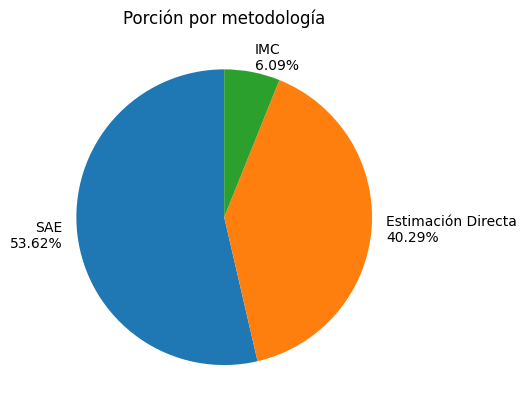

In [ ]:
# Agrupando por Metodología de Estimación y contando las ocurrencias
metodologia_counts = df['Metodología de Estimación'].value_counts()

# Creando las leyendas del grafico con porcentajes y nombres de metodología
labels = [f'{name}\n{percentage:.2f}%' for name, percentage in zip(metodologia_counts.index, (metodologia_counts / metodologia_counts.sum() * 100))]

plt.pie(metodologia_counts, labels=labels, startangle=90)
plt.title('Porción por metodología')
plt.show()

Región
VIII del Biobío                                  54
XIII Metropolitana de Santiago                   52
V de Valparaíso                                  38
VI del Libertador General Bernardo O'Higgins     33
IX de la Araucanía                               32
X de los Lagos                                   30
VII del Maule                                    30
IV de Coquimbo                                   15
XIV de los Ríos                                  12
XII de Magallanes y Antártica Chilena            10
XI Aysén del General Carlos Ibáñez del Campo     10
II de Antofagasta                                 9
III de Atacama                                    9
I de Tarapacá                                     7
XV de Arica y Parinacota                          4
Name: count, dtype: int64


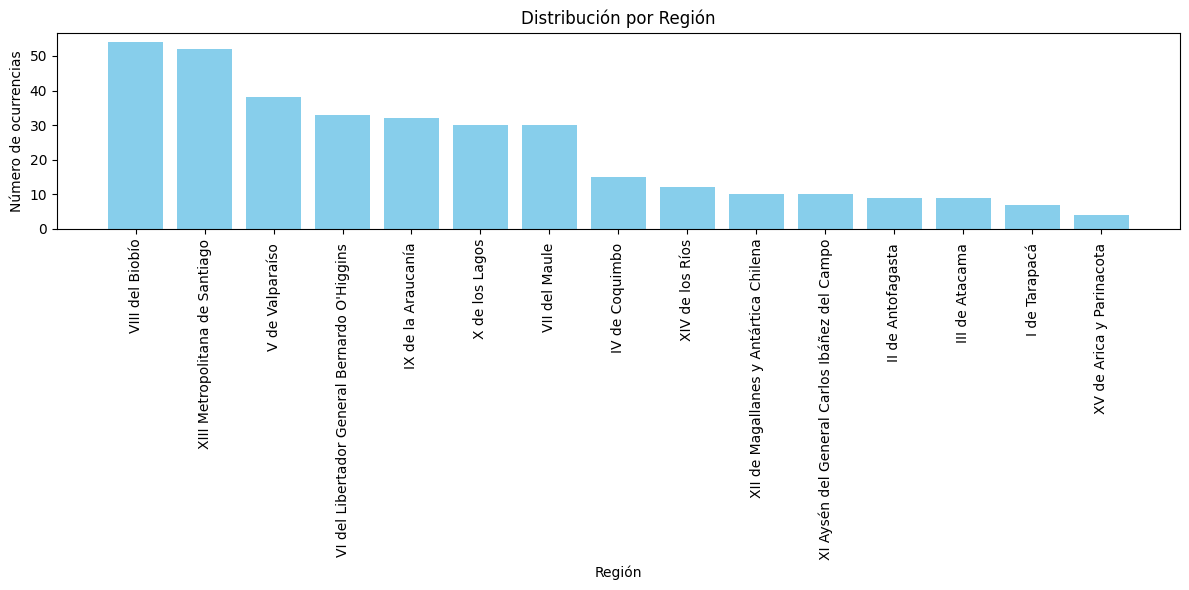

In [ ]:
#Se grafica cuantas personas hay por región dentro del df
region_count = df['Región'].value_counts()
print(region_count)
# Creando el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(region_count.index, region_count.values, color='skyblue')
plt.xlabel('Región')
plt.ylabel('Número de ocurrencias')
plt.title('Distribución por Región')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Región
Metropolitana         58
Valparaíso            38
Biobío                33
 O'Higgins            33
La Araucanía          32
Los Lagos             30
Maule                 30
Ñuble                 21
Coquimbo              15
Los Ríos              12
Magallanes            10
Aysén                 10
Antofagasta            9
Atacama                9
Tarapacá               7
Arica y Parinacota     4
Name: count, dtype: int64


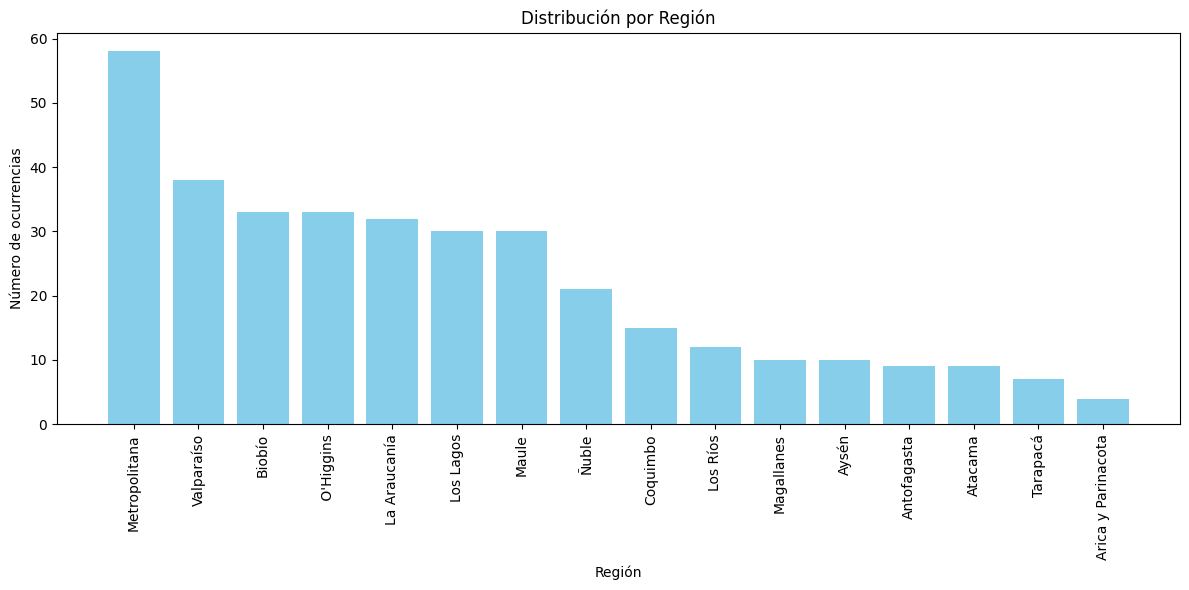

In [ ]:
#Se grafica cuantas personas hay por región dentro del df2
region_count = df2['Región'].value_counts()
print(region_count)
# Creando el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(region_count.index, region_count.values, color='skyblue')
plt.xlabel('Región')
plt.ylabel('Número de ocurrencias')
plt.title('Distribución por Región')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Se estandariza el formato de los datos de región para que sean compatibles con los datos de la data frame 2
mapeo_region = {
    'I de Tarapacá': 'Tarapacá',
    'II de Antofagasta': 'Antofagasta',
    'III de Atacama': 'Atacama',
    'IV de Coquimbo': 'Coquimbo',
    'V de Valparaíso': 'Valparaíso',
    'VI del Libertador General Bernardo O\'Higgins': 'O\'Higgins',
    'VII del Maule': 'Maule',
    'VIII del Biobío': 'Biobío',
    'IX de la Araucanía': 'La Araucanía',
    'X de los Lagos': 'Los Lagos',
    'XI Aysén del General Carlos Ibáñez del Campo': 'Aysén',
    'XII de Magallanes y Antártica Chilena': 'Magallanes',
    'XIII Metropolitana de Santiago': 'Metropolitana',
    'XIV de los Ríos': 'Los Ríos',
    'XV de Arica y Parinacota': 'Arica y Parinacota'
}

df['Región_Normalizada'] = df['Región'].map(mapeo_region)


<Figure size 1400x800 with 0 Axes>

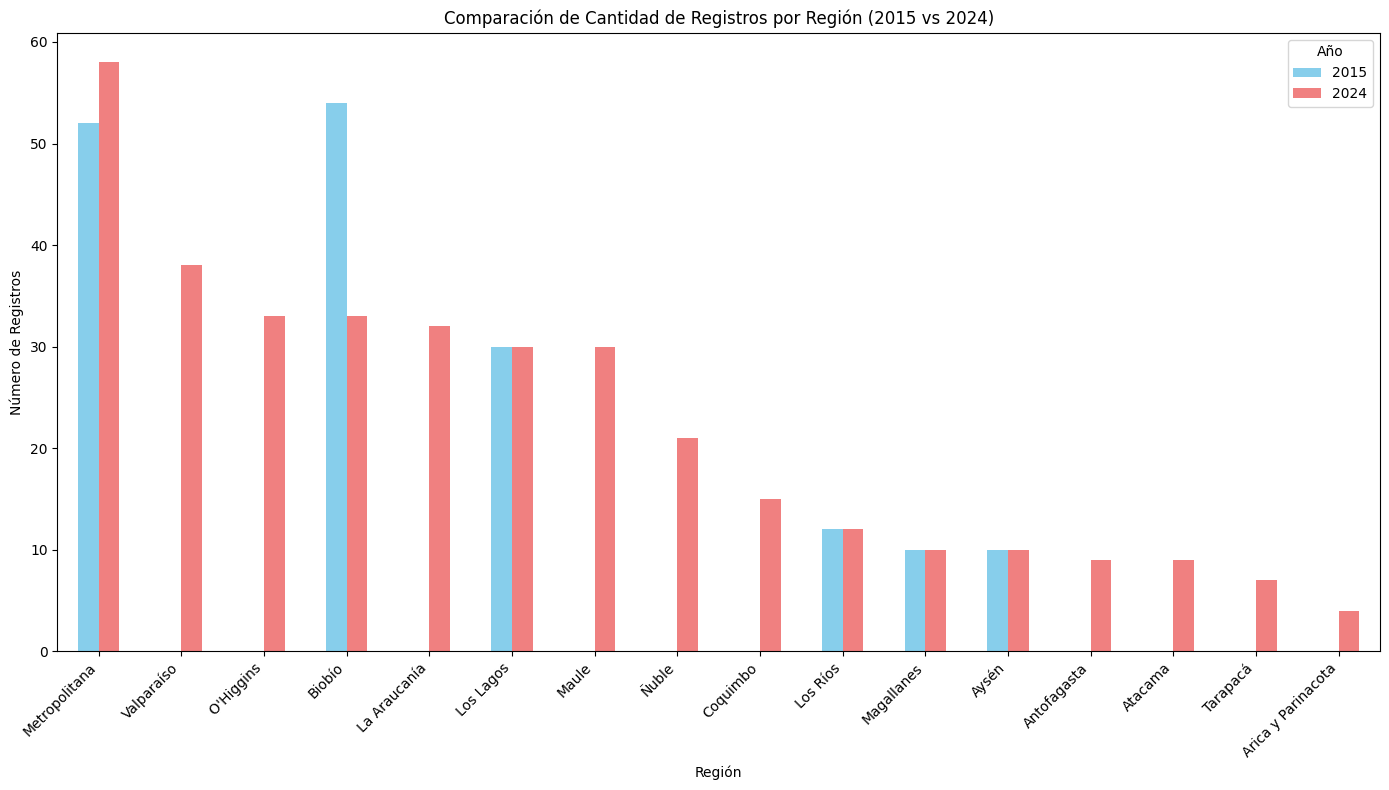

In [ ]:
# Calcular personas por region para 2015 (normalizado) y 2024
personas_por_region_2015 = df['Región_Normalizada'].value_counts().rename('2015')
personas_por_region_2024 = df2['Región'].value_counts().rename('2024')

# Combina los recuentos en un solo DataFrame para graficar
personas_por_regiones = pd.concat([personas_por_region_2015, personas_por_region_2024], axis=1).fillna(0)
personas_por_regiones = personas_por_regiones.sort_values(by='2024', ascending=False)

#Crear un gráfico de barras agrupadas
plt.figure(figsize=(14, 8))
personas_por_regiones.plot(kind='bar', figsize=(14, 8), color=['skyblue', 'lightcoral'])
plt.title('Comparación de Cantidad de Registros por Región (2015 vs 2024)')
plt.xlabel('Región')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Año')
plt.tight_layout()
plt.show()

In [ ]:
df


,Código comuna,Región,Nombre comuna,Número de personas en situación de pobreza por ingresos,Porcentaje de personas en situación de pobreza por ingresos,Límite inferior,Límite superior,Metodología de Estimación,Región_Normalizada
2,1101,I de Tarapacá,Iquique,9491.0000,0.053294,0.034605,0.081227,Estimación Directa,NaN
3,1107,I de Tarapacá,Alto Hospicio,9768.0000,0.085072,0.064137,0.112023,Estimación Directa,NaN
4,1401,I de Tarapacá,Pozo Almonte,1515.0000,0.103265,0.072762,0.144562,Estimación Directa,NaN
5,1402,I de Tarapacá,Camiña,300.2006,0.348665,0.276406,0.453704,SAE,NaN
6,1403,I de Tarapacá,Colchane,328.2058,0.239566,0.123635,0.235529,IMC,NaN
...,...,...,...,...,...,...,...,...,...
342,14204,XIV de los Ríos,Rio Bueno,5113.0000,0.171232,0.107617,0.261436,Estimación Directa,Los Ríos
343,15101,XV de Arica y Parinacota,Arica,14573.0000,0.088609,0.068152,0.114452,Estimación Directa,NaN
344,15102,XV de Arica y Parinacota,Camarones,217.5172,0.146674,0.072650,0.241199,SAE,NaN
345,15201,XV de Arica y Parinacota,Putre,240.0000,0.311284,0.219300,0.421043,Estimación Directa,NaN


In [ ]:
df2

,Código comuna,Región,Nombre comuna,Número de personas según proyecciones de población (*),Número de personas en situación de pobreza multidimensional (**),Porcentaje de personas en situacion de pobreza multidimensional 2024,Límite inferior,Límite superior,Presencia de la comuna en la muestra Casen,Tipo de estimación SAE (***)
2,1101,Tarapacá,Iquique,232455.000000,43108.781225,0.185450,0.163506,0.207394,Sí,Directa y Sintética (Fay-Herriot)
3,1107,Tarapacá,Alto Hospicio,144554.000000,40866.517698,0.282708,0.255357,0.310058,Sí,Directa y Sintética (Fay-Herriot)
4,1401,Tarapacá,Pozo Almonte,18811.000000,3646.420183,0.193845,0.142099,0.245592,Sí,Directa y Sintética (Fay-Herriot)
5,1402,Tarapacá,Camiña,1376.000000,427.722222,0.310845,0.222186,0.399503,Sí,Sintética
6,1403,Tarapacá,Colchane,1553.000000,504.646121,0.324949,0.242101,0.407797,Sí,Sintética
...,...,...,...,...,...,...,...,...,...,...
348,La metodología de áreas pequeñas busca realiza...,Metropolitana,Algarrobo,58352.086957,10316.947911,0.183742,0.137993,0.230286,Sí,Directa y Sintética (Fay-Herriot)
349,Las estimaciones presentadas se basan en la nu...,Metropolitana,Algarrobo,58352.086957,10316.947911,0.183742,0.137993,0.230286,Sí,Directa y Sintética (Fay-Herriot)
350,(*) Proyecciones de población comunal en vivie...,Metropolitana,Algarrobo,58352.086957,10316.947911,0.183742,0.137993,0.230286,Sí,Directa y Sintética (Fay-Herriot)
351,(**) Este número se obtiene de multiplicar las...,Metropolitana,Algarrobo,58352.086957,10316.947911,0.183742,0.137993,0.230286,Sí,Directa y Sintética (Fay-Herriot)


In [ ]:
#Este subset muestra el número total de personas en situación de pobreza multidimensional por región.
pobreza_por_region_df2 = df2.groupby('Región')['Número de personas en situación de pobreza multidimensional (**)'].sum().reset_index()
pobreza_por_region_df2.rename(columns={'Número de personas en situación de pobreza multidimensional (**)': 'Total de Personas en Pobreza Multidimensional'}, inplace=True)
display(pobreza_por_region_df2)

,Región,Total de Personas en Pobreza Multidimensional
0,O'Higgins,1.841060e+05
1,Antofagasta,1.247420e+05
2,Arica y Parinacota,4.897193e+04
3,Atacama,6.480644e+04
4,Aysén,1.313671e+04
5,Biobío,2.617340e+05
6,Coquimbo,1.505165e+05
7,La Araucanía,1.647396e+05
8,Los Lagos,1.489122e+05
9,Los Ríos,5.943754e+04


In [ ]:
# Crear segmentos para 'Total de Personas en Pobreza Multidimensional'
# Usamos qcut para dividir los datos en cuantiles (aproximadamente el mismo número de regiones en cada segmento)
pobreza_por_region_df2['Segmento de Pobreza'] = pd.qcut(pobreza_por_region_df2['Total de Personas en Pobreza Multidimensional'],
                                                        q=3, # Dividir en 3 segmentos
                                                        labels=['Bajo', 'Medio', 'Alto'],
                                                        duplicates='drop') # Manejar duplicados si los hay

# Mostrar el DataFrame con los nuevos segmentos
display(pobreza_por_region_df2.sort_values(by='Total de Personas en Pobreza Multidimensional', ascending=False))

# Contar cuántas regiones caen en cada segmento
print('\nConteo de Regiones por Segmento de Pobreza:')
display(pobreza_por_region_df2['Segmento de Pobreza'].value_counts())

,Región,Total de Personas en Pobreza Multidimensional,Segmento de Pobreza
12,Metropolitana,1.724587e+06,Alto
14,Valparaíso,3.238708e+05,Alto
5,Biobío,2.617340e+05,Alto
0,O'Higgins,1.841060e+05,Alto
7,La Araucanía,1.647396e+05,Alto
11,Maule,1.607155e+05,Alto
6,Coquimbo,1.505165e+05,Medio
8,Los Lagos,1.489122e+05,Medio
1,Antofagasta,1.247420e+05,Medio
13,Tarapacá,9.075758e+04,Medio



Conteo de Regiones por Segmento de Pobreza:


,count
Segmento de Pobreza,
Alto,6
Bajo,5
Medio,5


In [ ]:
# Calcular el promedio de 'Total de Personas en Pobreza Multidimensional' por 'Segmento de Pobreza'
promedio_por_segmento = pobreza_por_region_df2.groupby('Segmento de Pobreza')['Total de Personas en Pobreza Multidimensional'].mean()
display(promedio_por_segmento)

/tmp/ipykernel_52307/2996742699.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promedio_por_segmento = pobreza_por_region_df2.groupby('Segmento de Pobreza')['Total de Personas en Pobreza Multidimensional'].mean()


,Total de Personas en Pobreza Multidimensional
Segmento de Pobreza,
Bajo,39523.100596
Medio,120776.113697
Alto,469958.774225


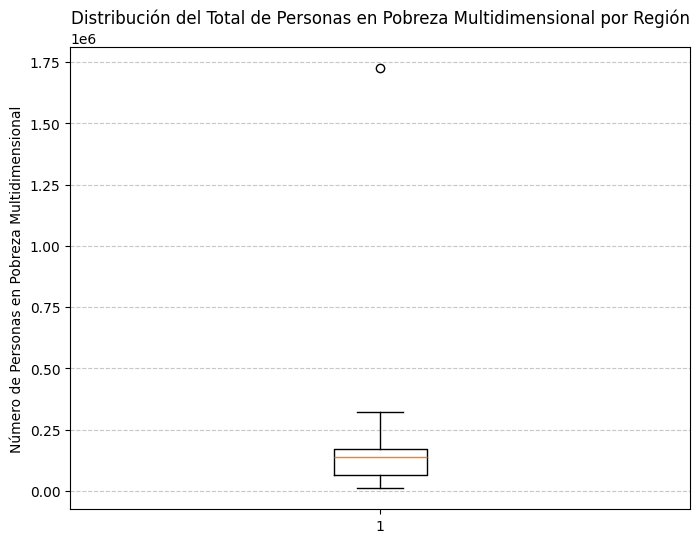

In [ ]:
#Se muestra la distribución del número de personas en pobreza multidimensional por región
plt.figure(figsize=(8, 6))
plt.boxplot(pobreza_por_region_df2['Total de Personas en Pobreza Multidimensional'])
plt.title('Distribución del Total de Personas en Pobreza Multidimensional por Región')
plt.ylabel('Número de Personas en Pobreza Multidimensional')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_52307/647487115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segmento de Pobreza', y='Total de Personas en Pobreza Multidimensional', data=pobreza_por_region_df2, order=['Bajo', 'Medio', 'Alto'], palette='viridis')


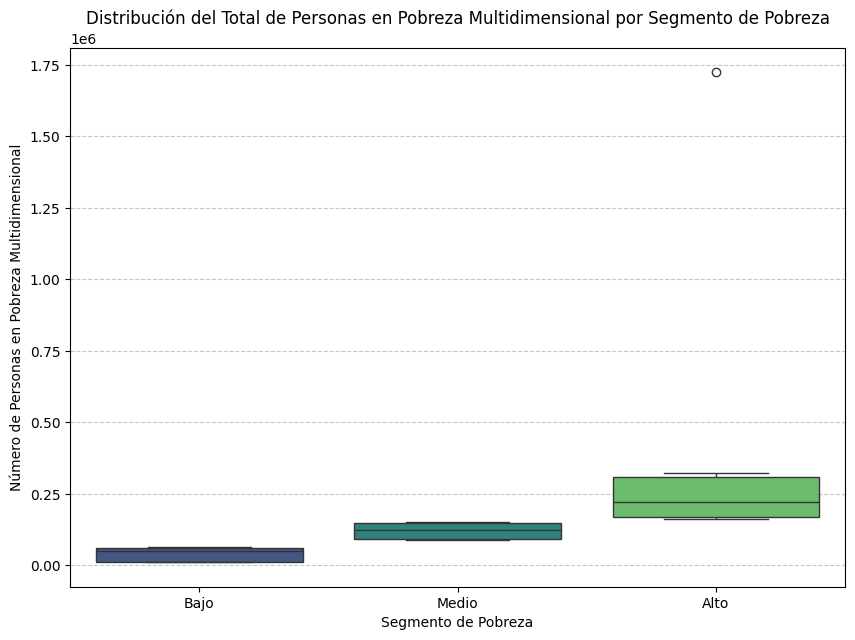

In [ ]:
#Se puede observar la distribución del número de personas en pobreza multidimensional para cada uno de los segmentos ('Bajo', 'Medio', 'Alto')
plt.figure(figsize=(10, 7))
sns.boxplot(x='Segmento de Pobreza', y='Total de Personas en Pobreza Multidimensional', data=pobreza_por_region_df2, order=['Bajo', 'Medio', 'Alto'], palette='viridis')
plt.title('Distribución del Total de Personas en Pobreza Multidimensional por Segmento de Pobreza')
plt.xlabel('Segmento de Pobreza')
plt.ylabel('Número de Personas en Pobreza Multidimensional')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_52307/432411571.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=est_type_counts.index, y=est_type_counts.values, palette='coolwarm')


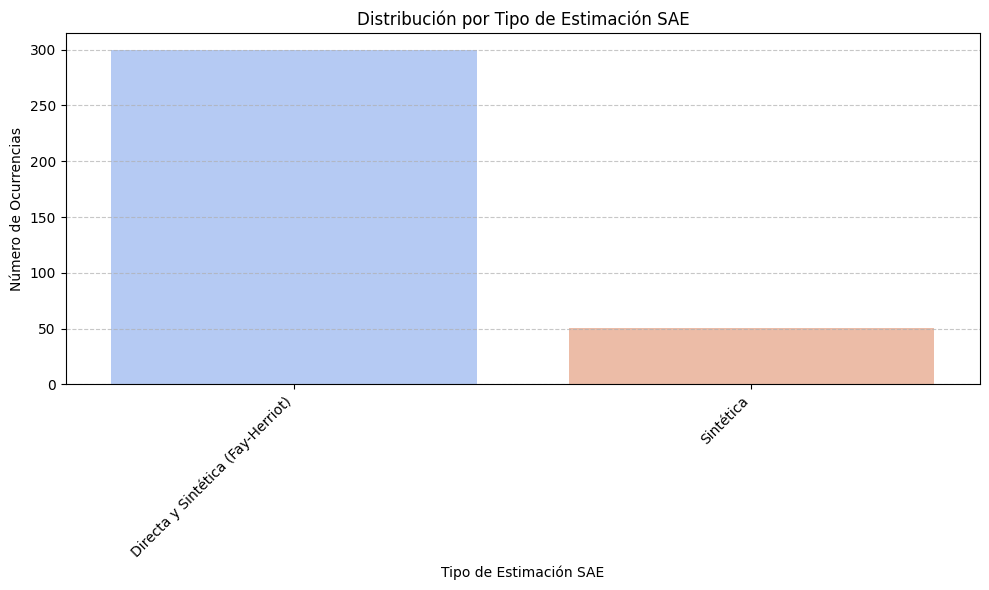

In [ ]:
#Este gráfico de barras muestra la frecuencia con la que aparece cada 'Tipo de estimación SAE (***)' en el DataFrame

#Calcular la frecuencia de cada tipo de estimación
est_type_counts = df2['Tipo de estimación SAE (***)'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=est_type_counts.index, y=est_type_counts.values, palette='coolwarm')
plt.title('Distribución por Tipo de Estimación SAE')
plt.xlabel('Tipo de Estimación SAE')
plt.ylabel('Número de Ocurrencias')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_52307/972040408.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metodologia_counts_df.index, y=metodologia_counts_df.values, palette='viridis')


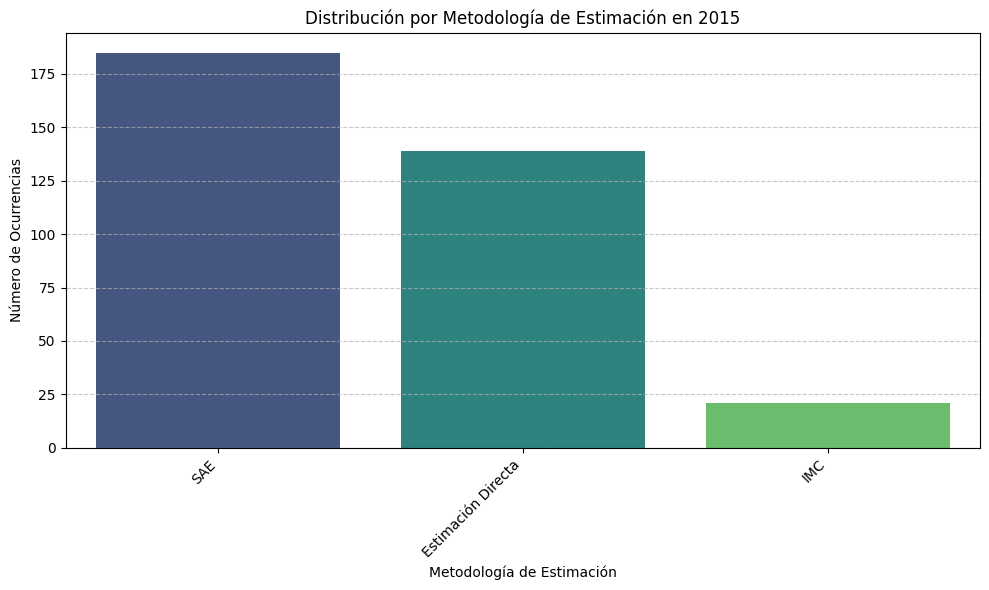

In [ ]:
# Calcular la frecuencia de cada metodología de estimación en df (ya calculada como 'metodologia_counts')
# Si df estuviera en su estado original, el código sería: metodologia_counts_df = df['Metodología de Estimación'].value_counts()

# Usamos la variable 'metodologia_counts' que ya existe en el kernel con los datos correctos
metodologia_counts_df = metodologia_counts

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=metodologia_counts_df.index, y=metodologia_counts_df.values, palette='viridis')
plt.title('Distribución por Metodología de Estimación en 2015')
plt.xlabel('Metodología de Estimación')
plt.ylabel('Número de Ocurrencias')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: >

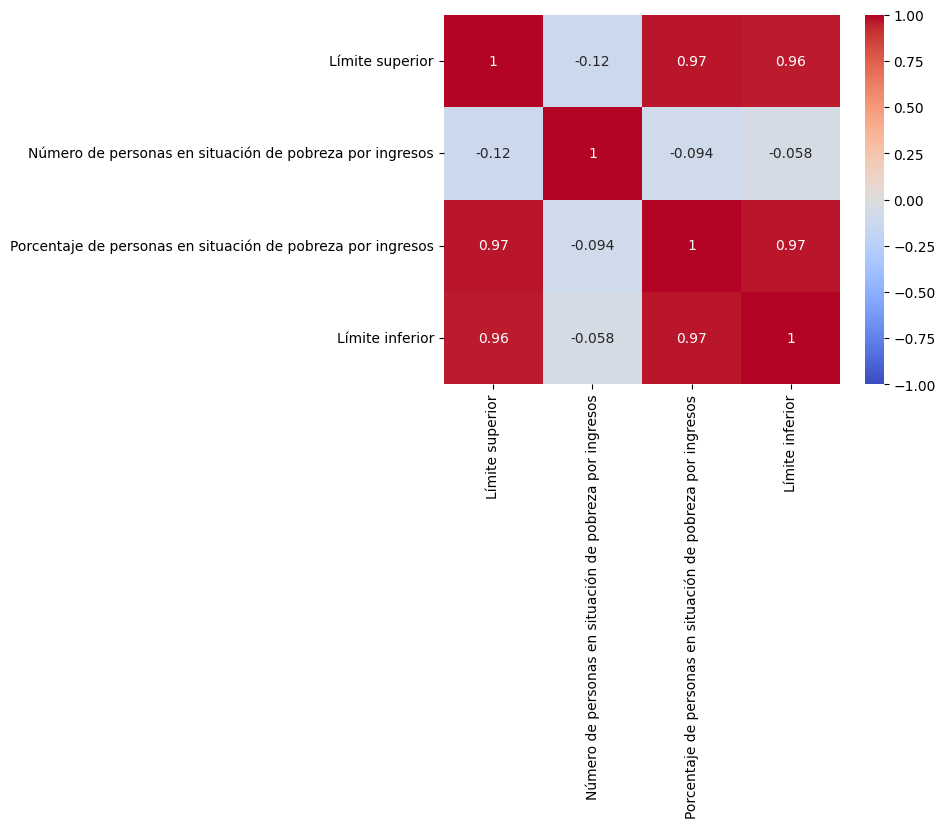

In [ ]:
#Correlación muy fuerte y positiva entre 'Número de personas en situación de pobreza por ingresos'
#y 'Porcentaje de personas en situación de pobreza por ingresos'. Esto es lógico, ya que
#un mayor número de personas en pobreza en una comuna se traduce directamente en
#un porcentaje más alto de pobreza multidimensional para esa comuna.

#Correlación muy fuerte y positiva entre 'Límite inferior' y 'Límite superior'. Estos dos valores
# definen un intervalo de confianza para una estimación. Si el límite inferior es más alto, es
#natural que el límite superior también lo sea, ya que están intrínsecamente relacionados.


sns.heatmap(df[cnum_df].corr(), vmin=-1 , vmax=+1, annot=True, cmap="coolwarm")

<Axes: >

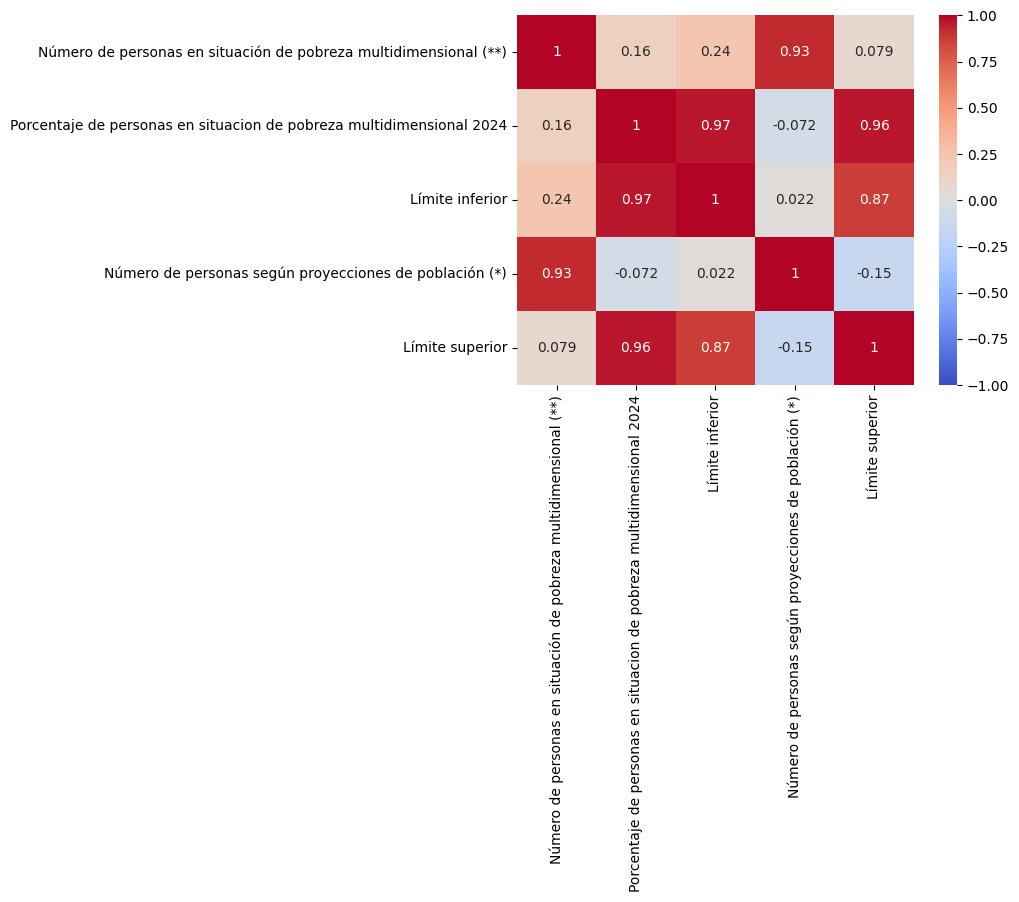

In [ ]:
#Correlación muy fuerte y positiva entre
#'Número de personas en situación de pobreza multidimensional ()'** y 'Porcentaje de personas
#en situación de pobreza multidimensional 2024'. Por la misma razón que en 2015,
#son dos formas de medir la misma situación.

#Correlación muy fuerte y positiva entre 'Límite inferior' y 'Límite superior'
#por la misma razón que en 2015.

#Correlación positiva entre 'Número de personas según proyecciones de población (*)'
#y 'Número de personas en situación de pobreza multidimensional ()'**. Es razonable que en
#comunas con mayor población, el número absoluto de personas en pobreza también sea mayor.

sns.heatmap(df2[cnum_df2].corr(), vmin=-1 , vmax=+1, annot=True, cmap="coolwarm")